# 03a - Spatial GNN Rollout on Aux Data

Minimal notebook: train a plain autoregressive spatial GNN on `data_aux_opt_lowT_448sims_noang_bidirect.pt` using 10 training simulations, validate by 100-step rollout on the remaining simulations, and plot predicted vs true rollout `p-ratio`.


In [12]:
# Requires: pip install -e .

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from course_project.config import ExperimentConfig
from course_project.data import load_dataset
from course_project.runner import run_graph_experiment
from course_project.utils import resolve_device



### Config


In [ ]:
dataset_path = '../data/data_aux_opt_lowT_448sims_noang_bidirect.pt'
output_root = '../results'
run_name = 'spatial_aux_opt_rollout_100'
force_train = True

device = resolve_device('cuda')
all_sims = load_dataset(dataset_path)
train_count = 20
val_count = len(all_sims) - train_count

cfg = ExperimentConfig(
    run_name=run_name,
    model_type='spatial',
    dataset_path=dataset_path,
    train_count=train_count,
    val_count=val_count,
    output_root=output_root,
    pos_dim=2,
    history=1,
    limit=20,
    hidden_size=128,
    n_layers=4,
    model_extras={'num_mlp': 3},
    learning_rate=1e-4,
    learning_rate_decay=0.999,
    weight_decay=0.0,
    epochs=20,
    val_every=5,
    rollout_every=5,
    cv_eval_every=0,
    freeze_normalizers_after_epoch=5,
    device=device,
    seed=234,
    rollout_steps=80,
)

print(json.dumps({
    'dataset_path': dataset_path,
    'train_count': train_count,
    'val_count': val_count,
    'rollout_steps': cfg.rollout_steps,
    'hidden_size': cfg.hidden_size,
    'n_layers': cfg.n_layers,
    'epochs': cfg.epochs,
    'device': device,
}, indent=2))



{
  "dataset_path": "../data/data_aux_opt_lowT_448sims_noang_bidirect.pt",
  "train_count": 10,
  "val_count": 90,
  "rollout_steps": 100,
  "hidden_size": 128,
  "n_layers": 4,
  "epochs": 40,
  "device": "cuda"
}


### Train Or Load


In [14]:
run_dir = Path(cfg.output_root) / cfg.run_name
metrics_path = run_dir / 'metrics.json'
preds_path = run_dir / 'rollout_predictions.csv'

if force_train or not metrics_path.exists() or not preds_path.exists():
    metrics = run_graph_experiment(cfg)
else:
    metrics = json.loads(metrics_path.read_text())

metrics



[run] spatial_aux_opt_rollout_100 model=spatial device=cuda output=../results/spatial_aux_opt_rollout_100
[run] training...
[ep   5/40] tr=0.921 va=0.9 lr=9.95e-05 roll=r2=-0.427 p=0.509 mse=0.00027 (90/90) t=60.6s
[ep  10/40] tr=0.909 va=0.898 lr=9.9e-05 roll=r2=0.0463 p=0.872 mse=0.000264 (90/90) t=60.7s
[ep  15/40] tr=0.895 va=0.898 lr=9.85e-05 roll=r2=-0.154 p=0.891 mse=0.000291 (90/90) t=158s
[ep  20/40] tr=0.867 va=0.906 lr=9.8e-05 roll=r2=-0.0939 p=0.596 mse=0.000381 (90/90) t=125s
[ep  25/40] tr=0.849 va=0.905 lr=9.75e-05 roll=r2=-0.226 p=0.714 mse=0.000353 (90/90) t=61.3s
[ep  30/40] tr=0.837 va=0.908 lr=9.7e-05 roll=r2=-0.12 p=0.72 mse=0.000338 (90/90) t=61.4s
[ep  35/40] tr=0.821 va=0.908 lr=9.66e-05 roll=r2=-0.451 p=0.525 mse=0.000453 (90/90) t=46.3s
[ep  40/40] tr=0.804 va=0.918 lr=9.61e-05 roll=r2=-0.789 p=0.571 mse=0.000568 (90/90) t=35.6s
[train] complete in 675s
[run] selected checkpoint epoch=10 rollout_r2=0.0463
[run] evaluating...
[run] done rollout_r2=0.0463 rollou

{'run_name': 'spatial_aux_opt_rollout_100',
 'model_type': 'spatial',
 'device': 'cuda',
 'selected_checkpoint': '../results/spatial_aux_opt_rollout_100/rollout_checkpoints/epoch_0010.pt',
 'best_epoch': 10,
 'best_score': 0.04629476462427229,
 'rollout_r2': 0.04629477305371266,
 'rollout_pearson_r': 0.8722649494395733,
 'rollout_pos_mse': 0.00026395975291961806,
 'used': 90,
 'total': 90}

### Training Curves


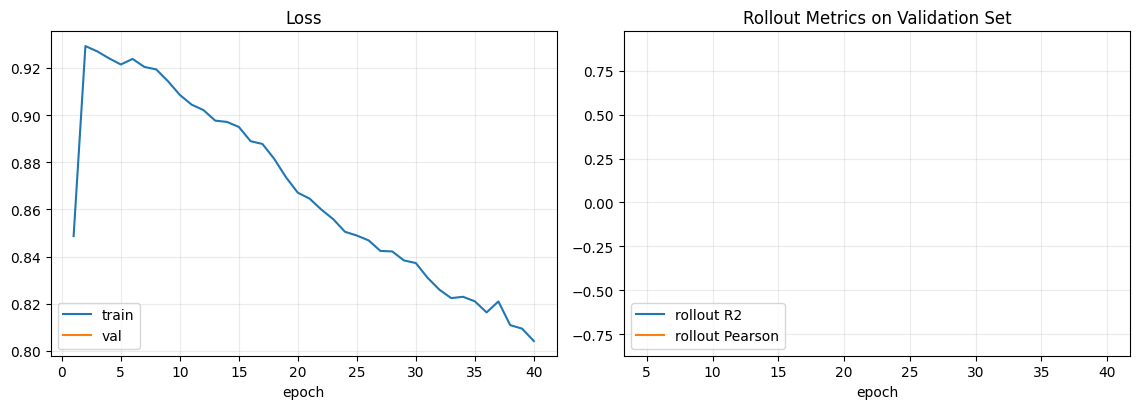

In [15]:
train_stats = pd.read_pickle(run_dir / 'train_stats.pt') if False else None
stats = __import__('torch').load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot(stats['epoch'], stats['loss'], label='train')
axes[0].plot(stats['epoch'], stats['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(stats['epoch'], stats['rollout_r2'], label='rollout R2')
axes[1].plot(stats['epoch'], stats['rollout_pearson_r'], label='rollout Pearson')
axes[1].set_title('Rollout Metrics on Validation Set')
axes[1].set_xlabel('epoch')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()



### Rollout p-Ratio Scatter


{
  "n": 90,
  "pearson": 0.8722649494395732,
  "spearman": 0.8805897048669259,
  "rmse": 0.38719877266160924
}


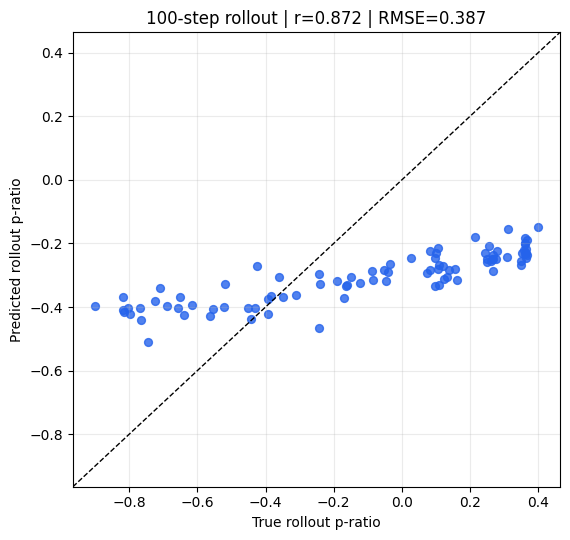

,sim_idx,target_index,pred_p_ratio,true_p_ratio,rollout_pos_mse
0,0,101,-0.255632,0.349351,0.000308
1,1,101,-0.232478,0.360491,0.000308
2,2,101,-0.508975,-0.746484,0.000292
3,3,101,-0.229099,0.364236,0.000308
4,4,101,-0.250156,0.276938,0.000256


In [16]:
pred_df = pd.read_csv(preds_path)
pred_df = pred_df.rename(columns={
    'target_rollout_sides_p_ratio': 'true_p_ratio',
    'pred_rollout_p_ratio': 'pred_p_ratio',
})

scatter_stats = {
    'n': int(len(pred_df)),
    'pearson': float(pred_df['true_p_ratio'].corr(pred_df['pred_p_ratio'], method='pearson')),
    'spearman': float(pred_df['true_p_ratio'].corr(pred_df['pred_p_ratio'], method='spearman')),
    'rmse': float(np.sqrt(np.mean((pred_df['pred_p_ratio'] - pred_df['true_p_ratio']) ** 2))),
}
print(json.dumps(scatter_stats, indent=2))

fig, ax = plt.subplots(figsize=(5.8, 5.5))
ax.scatter(pred_df['true_p_ratio'], pred_df['pred_p_ratio'], s=32, alpha=0.8, color='#2563eb')
lims = [
    float(min(pred_df['true_p_ratio'].min(), pred_df['pred_p_ratio'].min())),
    float(max(pred_df['true_p_ratio'].max(), pred_df['pred_p_ratio'].max())),
]
pad = 0.05 * (lims[1] - lims[0] + 1e-8)
lims = [lims[0] - pad, lims[1] + pad]
ax.plot(lims, lims, 'k--', linewidth=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('True rollout p-ratio')
ax.set_ylabel('Predicted rollout p-ratio')
ax.set_title(f"100-step rollout | r={scatter_stats['pearson']:.3f} | RMSE={scatter_stats['rmse']:.3f}")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

pred_df.head()

